In [2]:

from google.colab import files
uploaded = files.upload()

Saving student_details.csv to student_details.csv


In [4]:
import pandas as pd

df = pd.read_csv('student_details.csv')
print(df.head())
print(df.columns)


  school sex  age address famsize Pstatus                           Medu  \
0     GP   F   18       U     GT3       A               higher education   
1     GP   F   17       U     GT3       T  primary education (4th grade)   
2     GP   F   15       U     LE3       T  primary education (4th grade)   
3     GP   F   15       U     GT3       T               higher education   
4     GP   F   16       U     GT3       T            secondary education   

                            Fedu     Mjob      Fjob  ... famrel freetime  \
0               higher education  at_home   teacher  ...      4        3   
1  primary education (4th grade)  at_home     other  ...      5        3   
2  primary education (4th grade)  at_home     other  ...      4        3   
3               5th to 9th grade   health  services  ...      3        2   
4            secondary education    other     other  ...      4        3   

   goout  Dalc  Walc health absences  G1  G2  G3  
0      4     1     1      3        

Load Data


In [5]:
import pandas as pd

df = pd.read_csv('student_details.csv')

# Clean column names
df.columns = df.columns.str.lower().str.strip()

print(df.head())

  school sex  age address famsize pstatus                           medu  \
0     GP   F   18       U     GT3       A               higher education   
1     GP   F   17       U     GT3       T  primary education (4th grade)   
2     GP   F   15       U     LE3       T  primary education (4th grade)   
3     GP   F   15       U     GT3       T               higher education   
4     GP   F   16       U     GT3       T            secondary education   

                            fedu     mjob      fjob  ... famrel freetime  \
0               higher education  at_home   teacher  ...      4        3   
1  primary education (4th grade)  at_home     other  ...      5        3   
2  primary education (4th grade)  at_home     other  ...      4        3   
3               5th to 9th grade   health  services  ...      3        2   
4            secondary education    other     other  ...      4        3   

   goout  dalc  walc health absences  g1  g2  g3  
0      4     1     1      3        

TEP 2: BASIC CLEANING

In [6]:
df.dropna(inplace=True)

ANALYSIS

**Study Time vs Final Grade**


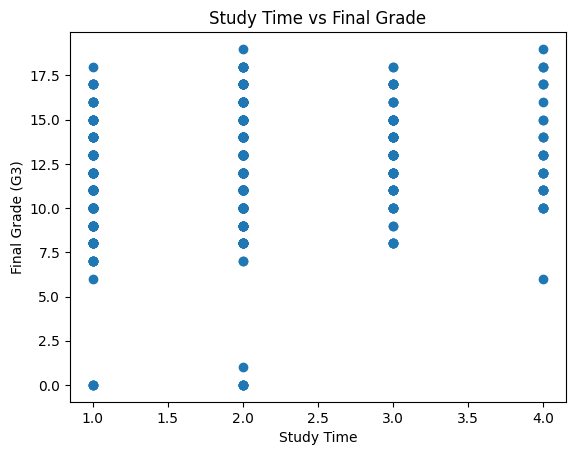

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['studytime'], df['g3'])
plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.title("Study Time vs Final Grade")
plt.show()

**Absences vs Performance**

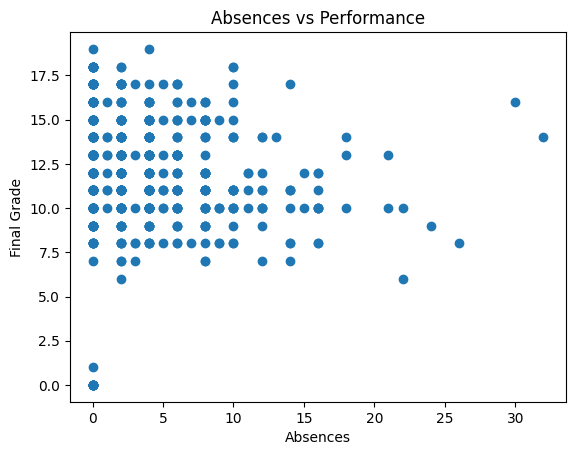

In [8]:
plt.figure()
plt.scatter(df['absences'], df['g3'])
plt.xlabel("Absences")
plt.ylabel("Final Grade")
plt.title("Absences vs Performance")
plt.show()

## **INSIGHTS**
- Higher study time improves final grades
- More absences reduce performance
- Previous scores (G1, G2) strongly affect final result

# ***MACHINE LEARNING MODEL***

In [9]:
df_encoded = pd.get_dummies(df, drop_first=True)

Define Features & Target

In [10]:
X = df_encoded.drop('g3', axis=1)
y = df_encoded['g3']

Training Model

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

STEP 6: EVALUATION

In [12]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.7692118007200421
R2 Score: 0.779814245586534


RESULTS

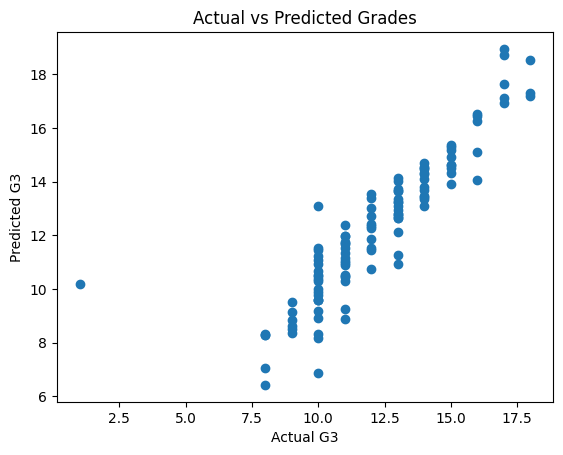

In [13]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Grades")
plt.show()

FEATURE IMPORTANCE

In [14]:
import pandas as pd

importance = pd.Series(model.coef_, index=X.columns)
top_features = importance.abs().sort_values(ascending=False).head(10)

print("Top Influencing Features:")
print(top_features)

Top Influencing Features:
g2               0.893903
fjob_teacher     0.543375
fjob_services    0.496730
fjob_health      0.472607
fjob_other       0.418017
school_MS        0.340809
failures         0.293340
nursery_yes      0.288120
schoolsup_yes    0.276737
paid_yes         0.257545
dtype: float64


# **Conclusion:**
- G1 and G2 are strongest predictors of final grade
- Study time positively impacts performance
- Absences negatively affect grades
- Model can help identify at-risk students early